# 11 Rigid Body Motion


## Falling plank
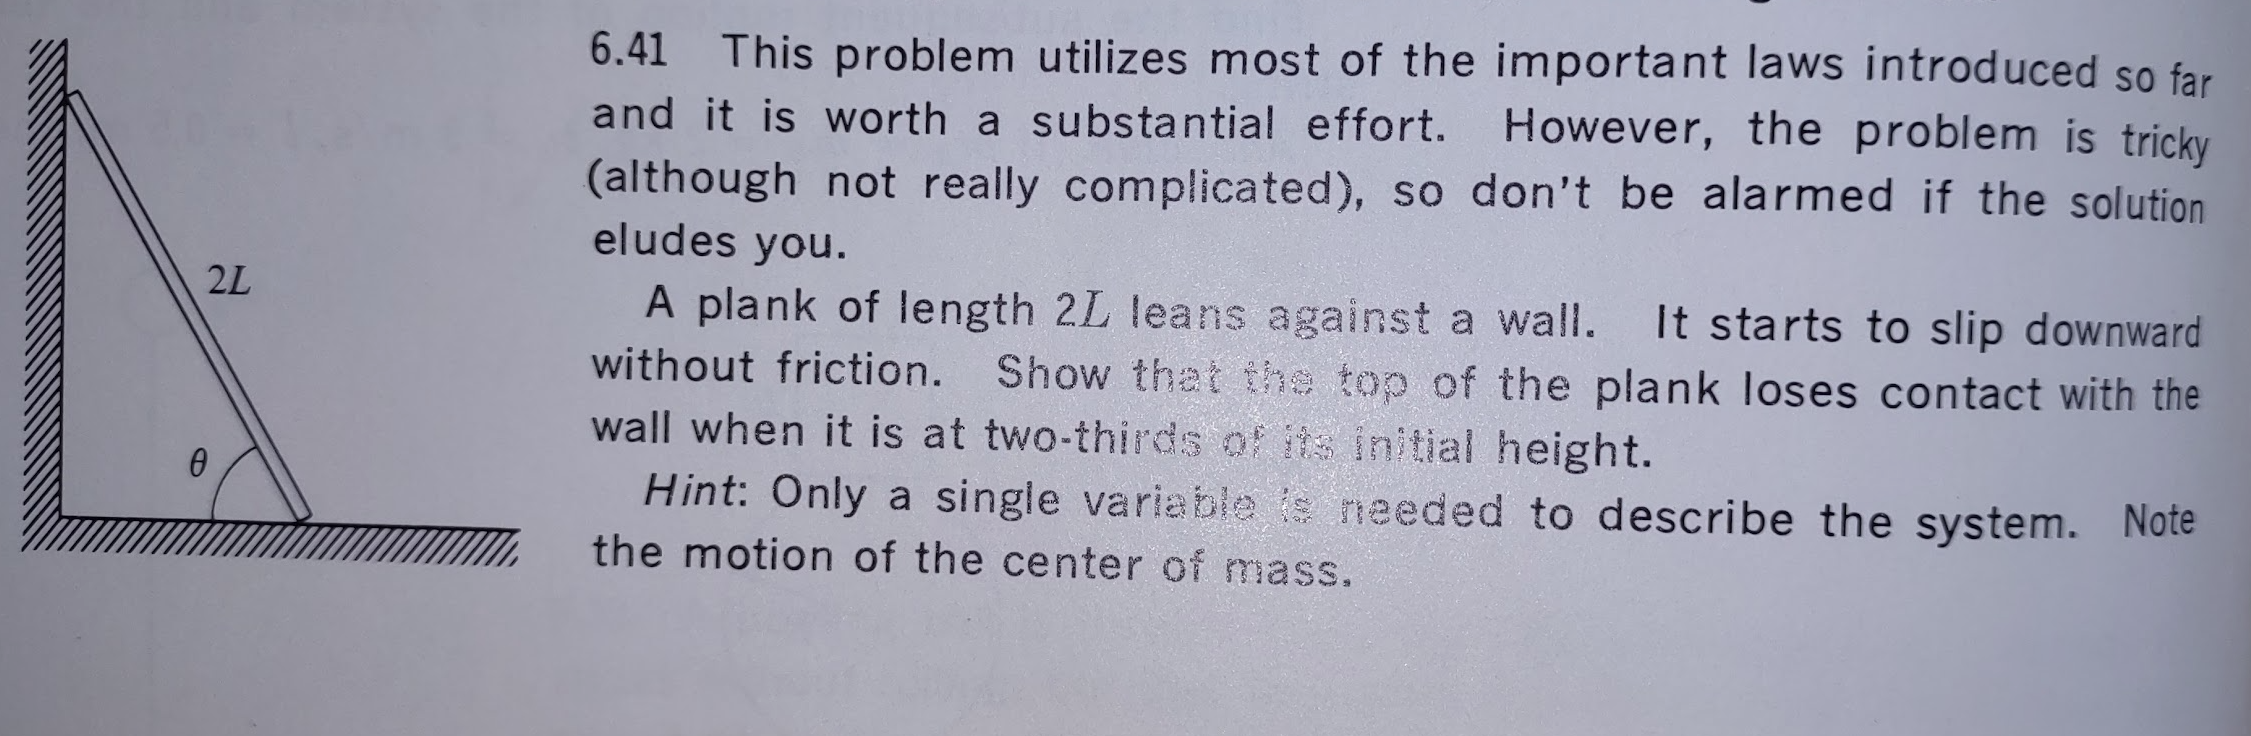 
from Kleppner/Kolenkow *An Introduction to Mechanics, McGraw-Hill, 1973*

We will do this problem, but with the addition of a coefficient of friction $\mu$ between the surfaces and the plank.

### Physics
Free body diagram:

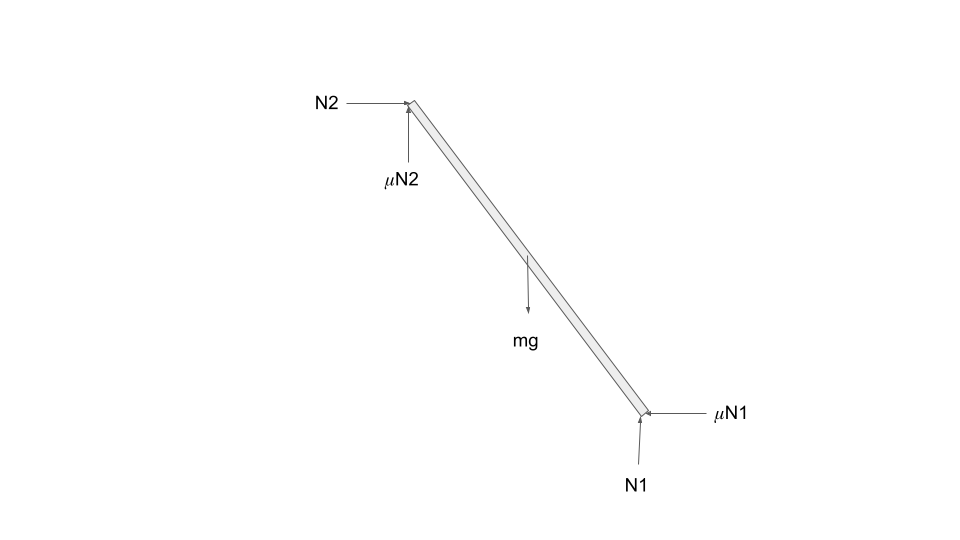


Our basic equations are $\vec{F}=m\vec{a}$ and $\tau=I\alpha$. (since torques are all into or out of the page, we use the one dimensional form of the equation.  Here the force is F, m mass, a acceleration, $\tau$, torque, I moment of inertia, and $\alpha$ angular acceleration.  We know that the net force results in acceleration of the center of mass, and the torque provides for motion around the center of mass.



$$\vec{F}=(N_2-\mu N_1,N_1+\mu N_2-mg,0)=m\vec{a}$$

We could think about having x and y accelerations independent, but the geometry constraint is  
$\vec{x}=(L\cos\theta,L\sin\theta,0),$= position of center of mass (center of plank).

Thus $\vec{v}=(-L\sin\theta\dot{\theta},L\cos\theta\dot{\theta},0)$ and $\vec{a}=(-L\cos\theta\dot{\theta}^2-L\sin\theta\ddot{\theta},-L\sin\theta\dot{\theta}^2+L\cos\theta\ddot{\theta},0)$

The x-equation gives us $N_2-\mu N_1 =-mL\cos\theta\dot{\theta}^2-mL\sin\theta\ddot{\theta}$ and the y-equation $N_1+\mu N_2=mg-mL\sin\theta\dot{\theta}^2+mL\cos\theta\ddot{\theta}.$

The torque equation, around the center of mass  gives us $$\frac{mL^2}{3}\ddot{\theta}=N_2L\sin\theta+\mu N_2 L \cos\theta -N_1 L\cos\theta+\mu N_1 L\sin\theta.$$

where we have used the fact that $I=\frac{m(2L)^2}{12}$ for the torque around the center of a rod of length 2L.  

### Numerics:

We want to solve this ordinary differential equation with solve_ivp.  The independent variable will be time, since we have time derivatives.  For each step of the integration, solve_ivp will call our function with a given angle $\theta$ and angular velocity $\dot{\theta}.$  With those given, we have three equations in three unknowns- N1, N2, and $\ddot{\theta};$ since our equations are non-linear we will solve them using scipy.optimize.root, and return $\ddot{\theta}.$

The plank eventually leaves the wall- at the time when $N1=0$. At that point in time our equations need to change, which is straightforward but we will stop the integration at that time.  This allows us to demonstrate the "events" parameter in solve_ivp, which enables us to stop the integration when a function goes to zero. 

### Validation

We will integrate the power $\mu N_i v_{i}$ to get the work done against friction. Here $i$ labels the ends of the plank, and $v_i$ is the velocity of the plank normal to the surface.  Note that the position of the center of mass is $$\vec{x_c}=L(\cos\theta,\sin\theta,0)$$ so the velocity of the center of mass is $$\vec{v_c}=L\omega(-\sin\theta,\cos\theta,0)$$ The vertical velocity of the left end of the plank is twice the vertical velocity of the cm, and the horizontal velocity of the bottom is twice the horizontal velocity of the cm.  We can add the friction work that to the kinetic and potential energy of the plank $1/2 mv_{cm}^2+1/2 I\omega^2+mgh$ to check conservation of energy.

  message: A termination event occurred.
  success: True
   status: 1
        t: [ 0.000e+00  1.306e-02 ...  1.052e+00  1.058e+00]
        y: [[ 1.000e+00  9.999e-01 ...  5.540e-01  5.477e-01]
            [ 0.000e+00 -8.841e-03 ... -9.908e-01 -1.000e+00]
            [ 0.000e+00 -3.889e-03 ... -1.891e+01 -1.897e+01]]
      sol: None
 t_events: [array([ 1.058e+00])]
 y_events: [array([[ 5.477e-01, -1.000e+00, -1.897e+01]])]
     nfev: 92
     njev: 0
      nlu: 0
  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.318e-03 ...  1.053e+00  1.058e+00]
        y: [[ 1.000e+00  1.000e+00 ...  5.530e-01  5.477e-01]
            [ 0.000e+00 -3.601e-03 ... -9.923e-01 -1.000e+00]
            [ 0.000e+00 -6.450e-04 ... -1.892e+01 -1.897e+01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 92
     njev: 0
      nlu: 0


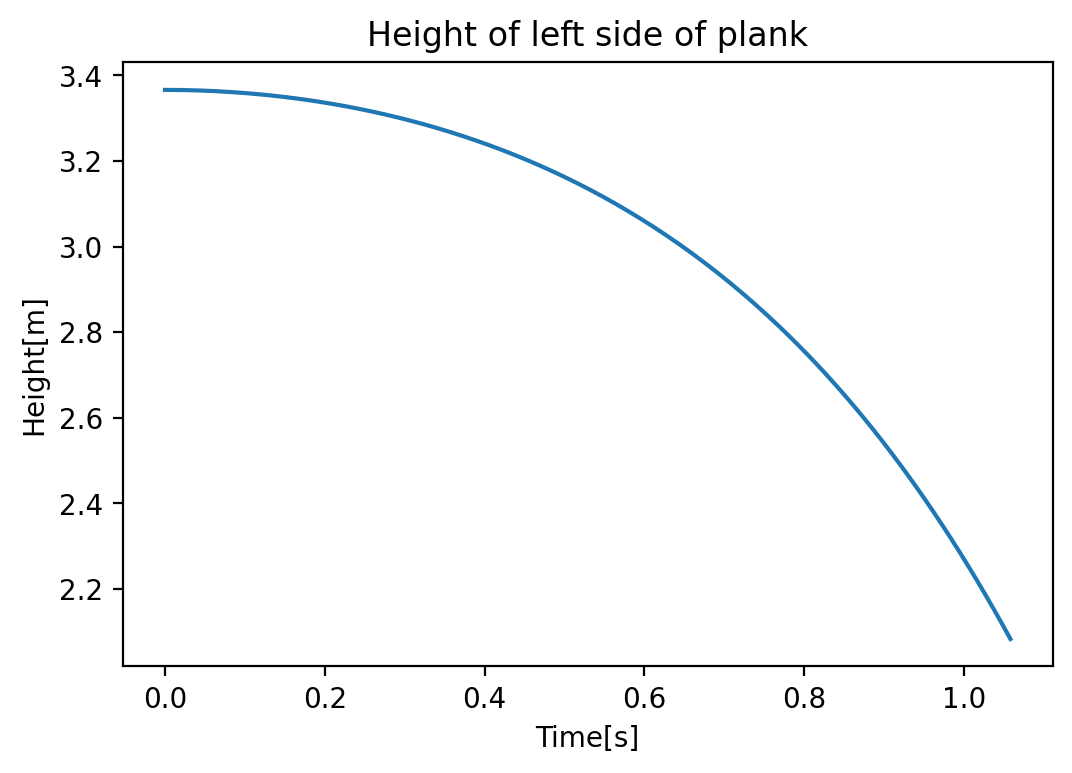

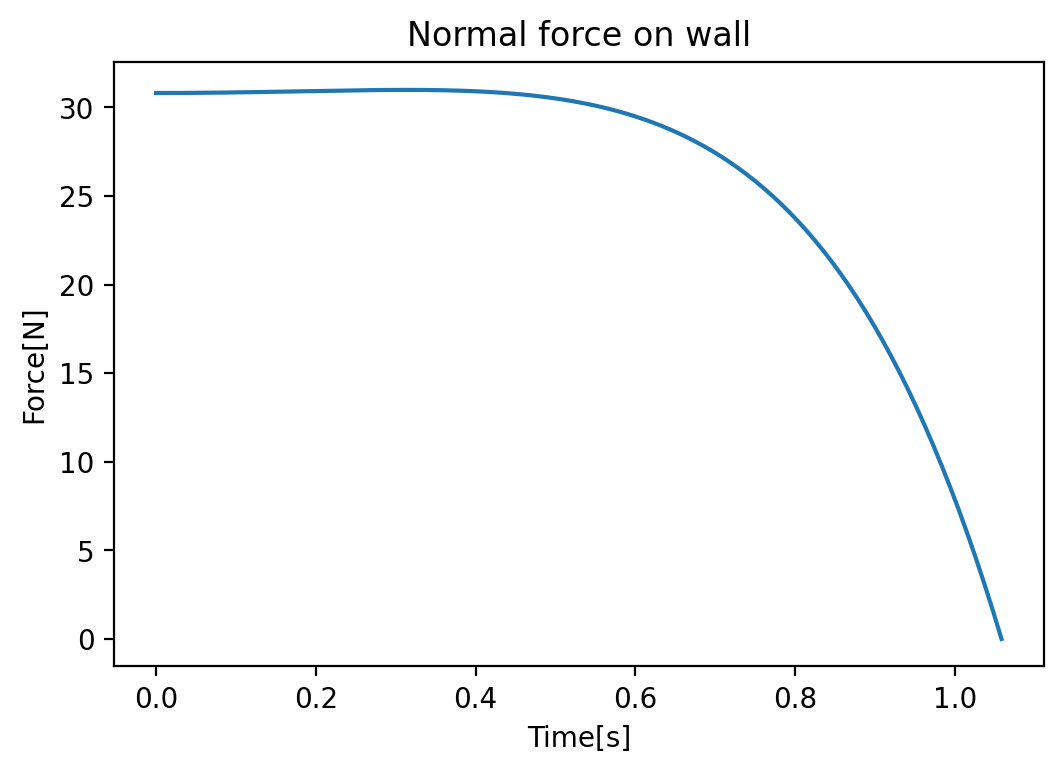

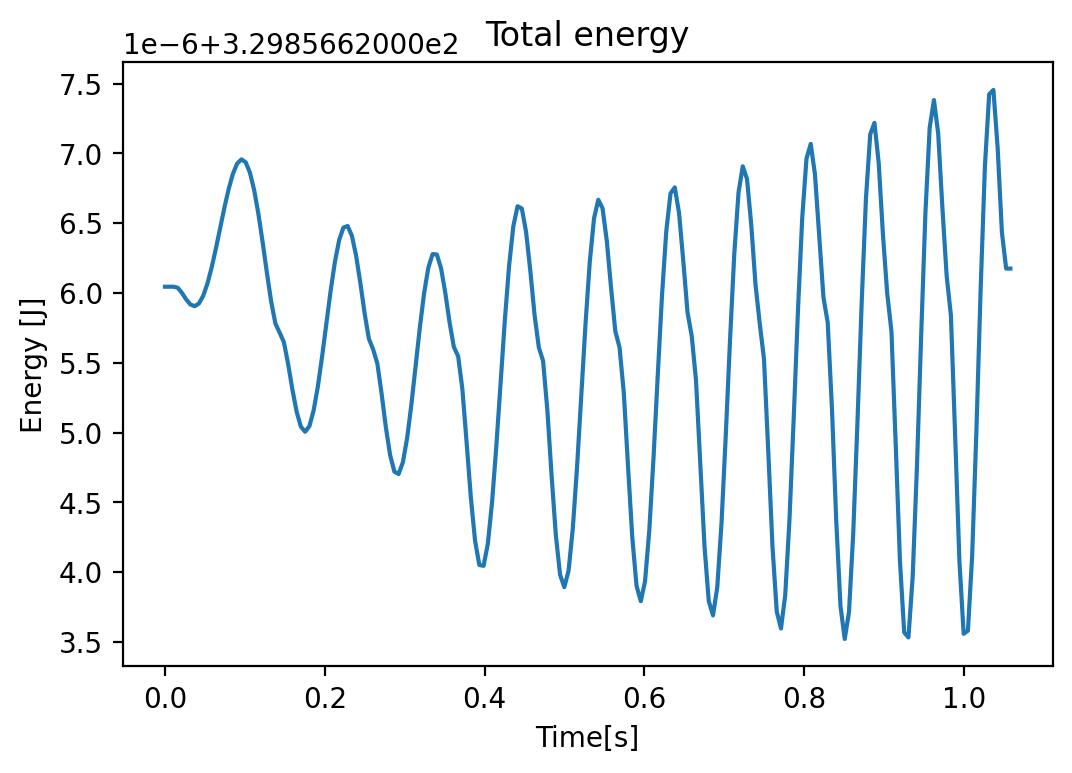

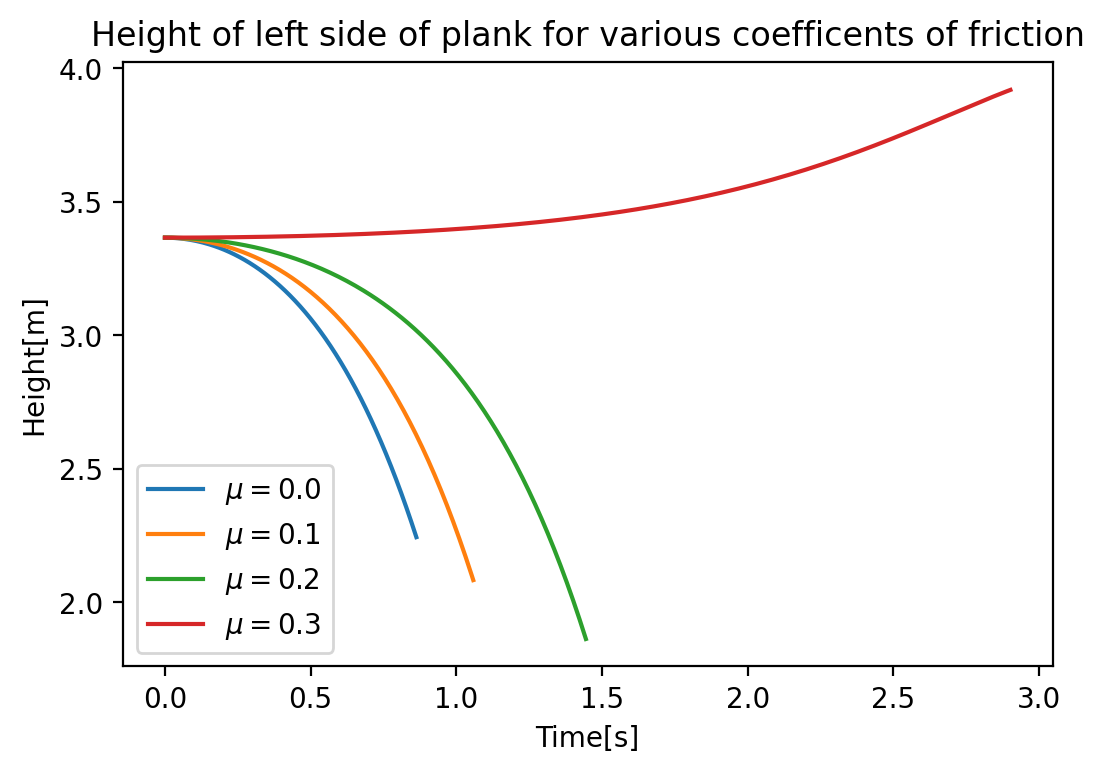

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('figure',dpi=200)

from scipy.integrate import solve_ivp
from scipy.optimize import root
g=9.8
L=4 #m
mu=0.1
m=10 #kg

def equations(x,theta,omega):  #equations that have a zero and allow us to solve for N1,N2,alpha
    N1,N2,alpha=x
#    theta,omega=args
    return np.array([N2-mu*N1+m*L*np.cos(theta)*omega**2+m*L*np.sin(theta)*alpha, 
            N1+mu*N2-m*g+m*L*np.sin(theta)*omega**2-m*L*np.cos(theta)*alpha,
           m*L**2/3*alpha-N2*L*np.sin(theta)+N1*L*np.cos(theta)-mu*N2*L*np.cos(theta)-mu*N1*L*np.sin(theta)])  #validation-- caught the /2 in the torques

def N2func(t,x):  #event function, to stop solve_ivp
    theta,omega,power=x
    rt=root(equations,np.array([m*g,m*g*np.sin(theta), g/L*np.cos(theta)]),args=(theta,omega))
    return rt.x[1]
N2func.terminal=True
    
def dthetadt(t,x):
    theta,omega,power=x
    rt=root(equations,np.array([m*g,m*g*np.sin(theta), g/L*np.cos(theta)]),args=(theta,omega))
    N1=rt.x[0]
    N2=rt.x[1]
    v2=2*L*np.cos(theta)*omega  #validation -twice the vertical velocity of the cm
    v1=-2*L*np.sin(theta)*omega # validation- twice the horizontal velocity of cm 
    power=-mu*N1*v1+mu*N2*v2
#    print(power,-N1*v1,N2*v2)
#    return [omega, -2*g/L*np.cos(theta)/(1./3+2*np.cos(theta)*np.sin(theta))]
    return [omega,rt.x[2],power]
s=solve_ivp(dthetadt,(0,2),[1,0,0],events=N2func,rtol=1e-10 )
print(s)
tlist=np.linspace(0,s.t_events[0][0],200)
s2=solve_ivp(dthetadt,(0,s.t_events[0][0]),[1,0,0],t_eval=tlist,rtol=1e-10 )
print(s2)
plt.plot(tlist,L*np.sin(s2.y[0,:]))
plt.title("Height of left side of plank")
plt.xlabel("Time[s]")
plt.ylabel("Height[m]")
plt.show()
N2list=[N2func(0,yy)for yy in s2.y.transpose()]
plt.plot(tlist,N2list)
plt.title("Normal force on wall")
plt.xlabel("Time[s]")
plt.ylabel("Force[N]")
plt.show()
#now calculate energy for each saved solution
energyList=[]
for yy in s2.y.transpose():
    theta,omega,work=yy
    energy=m*g*L*np.sin(theta)+1/2*m*(L*omega)**2+1/2*1/3*m*L**2*omega**2-work
    energyList.append(energy)
plt.plot(tlist,energyList)
plt.title("Total energy")
plt.xlabel("Time[s]")
plt.ylabel("Energy [J]")
plt.show()

for muentry in [0.0,0.1,0.2,0.3]:
    mu=muentry
    s=solve_ivp(dthetadt,(0,3),[1,0,0],events=N2func,rtol=1e-10 )
    tlist=np.linspace(0,s.t_events[0][0],200)
    s2=solve_ivp(dthetadt,(0,s.t_events[0][0]),[1,0,0],t_eval=tlist,rtol=1e-10 )
    plt.plot(tlist,L*np.sin(s2.y[0,:]),label=f'$\mu={mu}$')

plt.legend()
plt.title("Height of left side of plank for various coefficents of friction")
plt.xlabel("Time[s]")
plt.ylabel("Height[m]")
plt.show()
    



What is physically happening when $\mu=0.3$?    

In [108]:
help(solve_ivp)

Help on function solve_ivp in module scipy.integrate._ivp.ivp:

solve_ivp(fun, t_span, y0, method='RK45', t_eval=None, dense_output=False, events=None, vectorized=False, args=None, **options)
    Solve an initial value problem for a system of ODEs.
    
    This function numerically integrates a system of ordinary differential
    equations given an initial value::
    
        dy / dt = f(t, y)
        y(t0) = y0
    
    Here t is a 1-D independent variable (time), y(t) is an
    N-D vector-valued function (state), and an N-D
    vector-valued function f(t, y) determines the differential equations.
    The goal is to find y(t) approximately satisfying the differential
    equations, given an initial value y(t0)=y0.
    
    Some of the solvers support integration in the complex domain, but note
    that for stiff ODE solvers, the right-hand side must be
    complex-differentiable (satisfy Cauchy-Riemann equations [11]_).
    To solve a problem in the complex domain, pass y0 with a co